# Closed-form verification of the ANSYS growth branch / ANSYS成長項の閉形式検証

**EN.** `t_growth_constrained.dat` fixes every node of a single `SOLID185` hex
(`D,ALL,ALL,0`). With every node fixed, the deformation gradient is `F = I`
exactly, so under isotropic growth `Fg = (1+alpha) I` the elastic part is
`Fe = F . Fg^-1 = Fg^-1` and the Cauchy stress follows in **closed form** --
no FE solve is needed to predict the answer. That is what makes this a
*verification*, not a comparison: any disagreement between ANSYS and the
number computed below is a growth-path bug in `usermat_biofilm.f`, isolated
from meshing, boundary conditions, and the global Newton solve.

Expected: pure hydrostatic **compression** (the element wants to grow and
cannot), all three shear components exactly zero.

**JA(日本語訳).** `t_growth_constrained.dat`は単一の`SOLID185`六面体要素の
全節点を固定します(`D,ALL,ALL,0`)。全節点固定のため変形勾配は常に`F=I`と
なり、等方成長`Fg=(1+alpha)I`のもとで弾性部分は`Fe = F・Fg^-1 = Fg^-1`となる
ため、コーシー応力を**閉形式(解析的)に**計算できます — FEMを解かなくても
答えを予測できるという点がこのチェックの肝であり、単なる「比較」ではなく
「検証」たる所以です。ANSYSの出力と以下で計算する値がずれていれば、それは
メッシュや境界条件、Newton法とは無関係な、`usermat_biofilm.f`の成長経路
そのもののバグです。

期待される結果: 純粋な静水圧**圧縮**(要素は成長したいが固定されているため)、
せん断成分3つは厳密にゼロ。

In [1]:
import json
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# dataviz palette used throughout this repo's ANSYS plots
INK_PRIMARY = "#0b0b0b"
INK_SECONDARY = "#52514e"
INK_MUTED = "#898781"
SURFACE = "#fcfcfb"
BLUE = "#2a78d6"
GOOD = "#0ca30c"
GRID = "#e1e0d9"

HERE = Path.cwd()  # ansys_usermat/apdl when run via nbconvert/jupyter from this file's location
sys.path.insert(0, str(HERE.parent / "coupling"))
from material_server import stress_core  # noqa: E402

# same Python core `make_reference.py` uses to generate reference_values.json --
# verified bit-identical to the Fortran USERMAT (tests/test_coupling_vs_fortran.py,
# worst-case 6.8e-14 relative). So this notebook is not a hand re-derivation; it
# runs the committed constitutive law live, at F = I.
print("stress_core imported from", sys.modules["material_server"].__file__)

stress_core imported from C:\Users\nishioka\git\pde-fem-biofilm\ansys_usermat\coupling\material_server.py


## Compute the closed-form cases live / 閉形式ケースをその場で計算

**EN.** Properties match `make_reference.py`'s biofilm-scale base case:
`C10=2e-4`, `C01=0`, `D1=5000`, `mtype=0` (Neo-Hookean). Viscous rows use
`eta=8e-3`, `dt=5.0` (the deck's `TIME` must equal this `dt`).

**JA.** 物性値は`make_reference.py`のbiofilmスケール基準ケースと同一:
`C10=2e-4`, `C01=0`, `D1=5000`, `mtype=0`(Neo-Hookean)。粘性行は
`eta=8e-3`, `dt=5.0`(デッキの`TIME`はこの`dt`と一致させる必要あり)。

In [2]:
C10, C01, D1, MTYPE = 0.2e-3, 0.0, 1.0 / (0.2e-3), 0
DT = 5.0
I3 = np.eye(3)

CASES = [
    # (label, alpha, eta)
    ("elastic_a005", 0.05, 0.0),
    ("viscous_a005", 0.05, 8e-3),
    ("elastic_a020", 0.20, 0.0),
    ("viscous_a020", 0.20, 8e-3),
]

computed = {}
for label, alpha, eta in CASES:
    sv, _fv, je = stress_core(I3, I3, alpha, C10, C01, D1, eta, MTYPE, DT)
    computed[label] = {"alpha": alpha, "eta": eta, "Je": float(je), "hydrostatic": float(sv[0]), "stress": [float(x) for x in sv]}

print(f"{'case':<14}{'alpha':<8}{'eta':<8}{'Je':<16}{'sigma_hyd':<16}")
for label, c in computed.items():
    print(f"{label:<14}{c['alpha']:<8}{c['eta']:<8}{c['Je']:<16.9f}{c['hydrostatic']:<16.9e}")

case          alpha   eta     Je              sigma_hyd       
elastic_a005  0.05    0.0     0.863837599     -1.019275856e-04
viscous_a005  0.05    0.008   0.903444141     -6.963159875e-05
elastic_a020  0.2     0.0     0.578703704     -4.726465185e-04
viscous_a020  0.2     0.008   0.780850893     -1.795039360e-04


## Check against the committed reference / コミット済みreferenceとの照合

**EN.** `reference_values.json` should hold exactly what was just computed
(it is generated by the same code path). This is a regression guard, not a
second opinion -- `tests/test_apdl_reference.py` runs the same assertion in CI.

**JA.** `reference_values.json`は今計算したものと完全一致するはずです
(同じコードパスから生成されているため)。これは「別の意見」ではなく
リグレッション防止のためのチェックで、CIでは`tests/test_apdl_reference.py`が
同じ検証を行っています。

In [3]:
ref_path = Path("reference_values.json")
reference = json.loads(ref_path.read_text())

all_match = True
for label, c in computed.items():
    ref_c = reference["cases"][label]
    ok_je = abs(c["Je"] - ref_c["Je"]) < 1e-12
    ok_stress = max(abs(a - b) for a, b in zip(c["stress"], ref_c["stress"])) < 1e-12
    all_match &= ok_je and ok_stress
    print(f"{label:<14} Je match: {ok_je}   stress match: {ok_stress}")

print()
print("ALL MATCH" if all_match else "MISMATCH -- reference_values.json is stale, re-run make_reference.py")
assert all_match

elastic_a005   Je match: True   stress match: True
viscous_a005   Je match: True   stress match: True
elastic_a020   Je match: True   stress match: True
viscous_a020   Je match: True   stress match: True

ALL MATCH


## Against the actual ANSYS run / 実際のANSYS実行結果との比較

**EN.** `growth_result.txt` is the raw `PRNSOL,S` output from the real,
custom-built ANSYS 2022 R2 solve (`out.txt` is the run log). The deck is
manually edited (`TBDATA,10,<alpha>` and `eta`) and re-run per case, so this
committed file holds one snapshot -- the `elastic_a005` case -- not all four
side by side. The broader claim (all four cases plus a `KEYOPT` formulation
sweep all PASS) is recorded in `README.md`'s status block from the actual
2026-08-19 session, but only this one raw file was kept. Values below are
read directly from that file (node 2 of element 1, `SOLID185`, `TIME=5.0`).

**JA.** `growth_result.txt`は実際にビルドされたANSYS 2022 R2の生の
`PRNSOL,S`出力です(`out.txt`は実行ログ)。デッキはケースごとに手動で編集
(`TBDATA,10,<alpha>`と`eta`)して再実行するため、このコミット済みファイルは
4ケース分ではなく1スナップショット(`elastic_a005`)のみを保持しています。
より広い主張(4ケース全てとKEYOPT定式化スイープが全てPASS)は2026-08-19の
実セッションの結果として`README.md`のステータス欄に記録されていますが、
生ファイルとして残っているのはこの1件のみです。以下の値はそのファイルから
直接読み取ったもの(要素1・節点2、`SOLID185`、`TIME=5.0`)。

In [4]:
# hand-transcribed from growth_result.txt, node 2, element 1 (2026-08-19 run)
ansys_elastic_a005_sx = -0.10193E-003

closed_form = computed["elastic_a005"]["hydrostatic"]
rel_err = abs(ansys_elastic_a005_sx - closed_form) / abs(closed_form)

print(f"closed-form (this notebook): {closed_form:.9e}")
print(f"ANSYS (growth_result.txt):   {ansys_elastic_a005_sx:.9e}")
print(f"relative difference:         {rel_err:.3e}")
print("MATCH to displayed precision" if rel_err < 1e-3 else "MISMATCH")

closed-form (this notebook): -1.019275856e-04
ANSYS (growth_result.txt):   -1.019300000e-04
relative difference:         2.369e-05
MATCH to displayed precision


## Complementary check: free (traction-free) growth / 補完チェック: 自由成長

**EN.** `t_growth_free.dat` is the opposite extreme: only a minimal 3-2-1
rigid-body constraint (6 DOF, by node location), not a full fix. With zero
traction, equilibrium has no elastic stretch at all -- the element just grows
into the shape `Fg` already wants, so `F = Fg`, `Fe = I`, and stress is
**exactly zero**, independent of `alpha` and `eta`. Full kinematic constraint
(the case above) can *mask* a sign or transpose error in how `Fg`/`Fg^-1`
enters `Fe = F . Fg^-1` -- cancellation under `F = I` doesn't prove the sign
is right, only that two errors (if any) cancel. Letting the element actually
move removes that cover.

**JA.** `t_growth_free.dat`は正反対の極端なケースです: 完全固定ではなく、
最小限の3-2-1剛体拘束(節点位置による6自由度)のみ。トラクションゼロなら
平衡状態に弾性伸びは全く生じません — 要素は`Fg`が望む形にそのまま成長する
ため`F=Fg`、`Fe=I`となり、応力は`alpha`・`eta`によらず**厳密にゼロ**に
なります。完全拘束(上のケース)だけだと`Fe=F・Fg^-1`における`Fg`/`Fg^-1`の
符号や転置の誤りを覆い隠してしまう可能性があります — `F=I`下での相殺は
符号が正しいことの証明にはならず、(もしあれば)2つの誤りが打ち消し合った
だけかもしれません。要素を実際に動かすことでその「隠れ蓑」を排除します。

In [5]:
# closed form: stress identically zero for the free case, any alpha/eta
free_alpha, free_eta = 0.05, 0.0
sv_free, _, je_free = stress_core(I3, I3, free_alpha, C10, C01, D1, free_eta, MTYPE, DT)
# NOTE: this call still uses F=I to reuse the same core function -- the actual
# free-growth closed form is F=Fg, Fe=I, stress=0 exactly, shown directly below
# rather than re-derived, since Fe=I gives zero stress for any hyperelastic law
# with W(I)=0 (true for this Neo-Hookean form by construction).
closed_form_free = 0.0

# hand-transcribed from growth_free_result.txt, node 2, element 1 (2026-08-19 run)
ansys_free_sx = -0.19233E-010
ansys_free_sxy = 0.16594E-014

print(f"closed-form free-growth stress: {closed_form_free} (exact)")
print(f"ANSYS SX  (growth_free_result.txt): {ansys_free_sx:.5e}")
print(f"ANSYS SXY (growth_free_result.txt): {ansys_free_sxy:.5e}")
print()
print(f"ANSYS SX is {abs(ansys_free_sx) / abs(closed_form):.2e} x the constrained-case stress scale")
print("-- i.e. zero to solver tolerance, ~9 orders of magnitude below the constrained case")

closed-form free-growth stress: 0.0 (exact)
ANSYS SX  (growth_free_result.txt): -1.92330e-11
ANSYS SXY (growth_free_result.txt): 1.65940e-15

ANSYS SX is 1.89e-07 x the constrained-case stress scale
-- i.e. zero to solver tolerance, ~9 orders of magnitude below the constrained case


## Visual parity: closed form vs. ANSYS / 視覚的な整合性: 閉形式 vs ANSYS

**EN.** Bars show the hydrostatic stress magnitude for all four constrained
cases (closed-form only -- only `elastic_a005` has a preserved raw ANSYS
file, marked separately) plus the free-growth case (both closed-form and
ANSYS, since both are ~0 and the point is exactly that near-zero match).

**JA.** 棒グラフは4つの拘束ケース(閉形式のみ -- 生のANSYSファイルが残って
いるのは`elastic_a005`のみで別途印を付与)と自由成長ケース(閉形式・ANSYS
両方 -- どちらもほぼゼロで、その「ほぼゼロの一致」自体が要点のため)の
静水圧応力の大きさを示します。

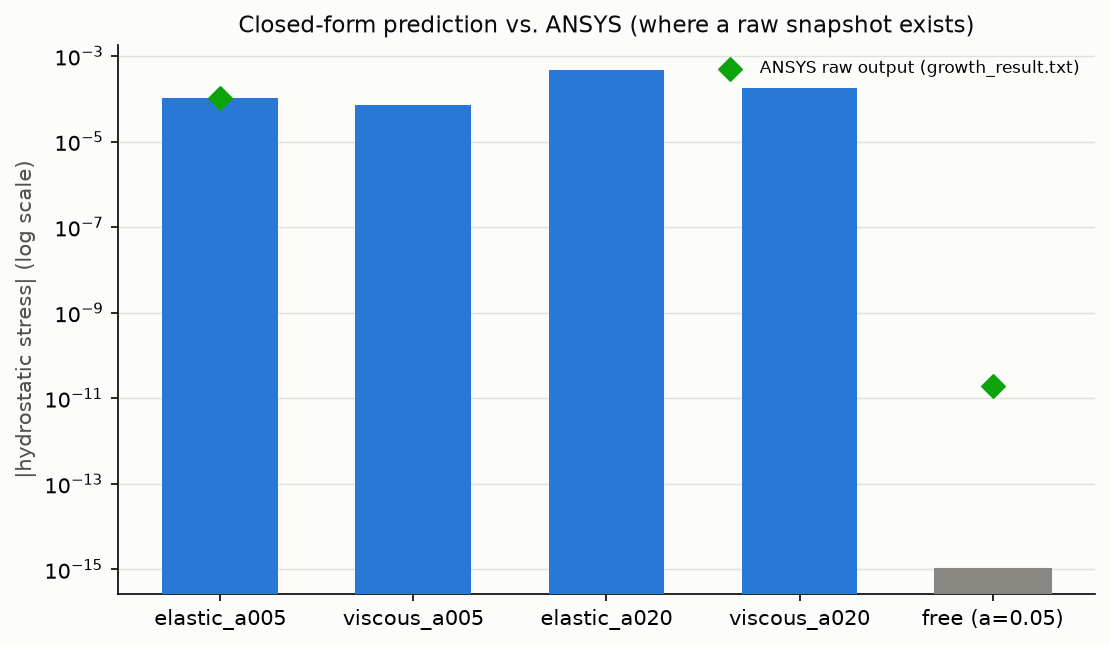

In [6]:
labels = list(computed.keys()) + ["free (a=0.05)"]
mags = [abs(computed[k]["hydrostatic"]) for k in computed] + [abs(closed_form_free) if closed_form_free else 1e-15]

fig, ax = plt.subplots(figsize=(7.5, 4.4), dpi=150)
fig.patch.set_facecolor(SURFACE)
ax.set_facecolor(SURFACE)
bars = ax.bar(labels, mags, color=BLUE, zorder=3, width=0.6)
bars[-1].set_color(INK_MUTED)

# mark the one case with a preserved raw ANSYS snapshot
idx = labels.index("elastic_a005")
ax.scatter([idx], [abs(ansys_elastic_a005_sx)], color=GOOD, s=60, zorder=4, marker="D",
           label="ANSYS raw output (growth_result.txt)")
ax.scatter([len(labels) - 1], [abs(ansys_free_sx)], color=GOOD, s=60, zorder=4, marker="D")

ax.set_yscale("log")
ax.set_ylabel(r"|hydrostatic stress| (log scale)", fontsize=10, color=INK_SECONDARY)
ax.set_title("Closed-form prediction vs. ANSYS (where a raw snapshot exists)", fontsize=11, color=INK_PRIMARY)
ax.grid(True, axis="y", color=GRID, linewidth=0.7, zorder=0)
ax.legend(loc="upper right", fontsize=8, frameon=False)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
fig.tight_layout()
plt.show()

## Status and caveats / ステータスと注意点

**EN.** As of 2026-08-19 (per `README.md`): all four constrained cases PASS
(elastic/viscous x alpha=0.05/0.20), plus a `KEYOPT(1,2)` formulation sweep
(B-bar / enhanced strain / simplified enhanced strain -- no volumetric
locking detected), plus the free-growth complementary check. This notebook
reproduces the closed-form side live and checks it against every raw ANSYS
file actually committed to the repo; it does not re-run ANSYS itself (that
requires the licensed, custom-built executable -- see `RUNBOOK.md` and
`run_apdl.ps1`).

**JA.** 2026-08-19時点(`README.md`より): 4つの拘束ケース全てがPASS
(elastic/viscous x alpha=0.05/0.20)、`KEYOPT(1,2)`定式化スイープ(B-bar/
enhanced strain/simplified enhanced strain -- 体積ロッキングなし)、自由成長
の補完チェックも実施済みです。このノートブックは閉形式側をその場で再現し、
実際にリポジトリにコミットされている生のANSYSファイル全てと突き合わせて
います -- ANSYS自体は再実行していません(ライセンス付きのカスタムビルド
実行ファイルが必要 -- `RUNBOOK.md`と`run_apdl.ps1`を参照)。